In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/train.csv')

In [ ]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data=np.array(data)

In [ ]:
data

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [7, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0]])

In [ ]:
m,n = data.shape

In [ ]:
print(m,n)

42000 785


In [ ]:
np.random.shuffle(data)

In [ ]:
data

array([[5, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0],
       ...,
       [3, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0]])

In [ ]:
train_data = data[0:int(0.8*m),:]
val_data = data[int(0.8*m):m,:]

In [ ]:
train_data.shape

(33600, 785)

In [ ]:
x_train = train_data[:,1:].T
x_train = x_train / 255.0
y_train = train_data[:,0]

x_val = val_data[:,1:].T
x_val = x_val / 255.0
y_val = val_data[:,0]

In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

(784, 33600)
(33600,)
(784, 8400)
(8400,)


In [ ]:
def initialize_parameters():
  W1 = np.random.randn(10,784) - 0.5
  B1 = np.random.randn(10,1) - 0.5
  W2 = np.random.randn(10,10) - 0.5
  B2 = np.random.randn(10,1) - 0.5
  return W1,B1,W2,B2

def ReLu(x):
  return np.maximum(x,0)

def softmax(x):
  return np.exp(x) / np.sum(np.exp(x))


def forward_propogation(W1,B1,W2,B2,x):
  Z1 = W1.dot(x) + B1
  A1 = ReLu(Z1)
  Z2 = W2.dot(A1) + B2
  A2 = softmax(Z2)
  return Z1,A1,Z2,A2

def one_hot_converter(y):
  one_hot_y = np.zeros((y.size,y.max()+1))
  one_hot_y[np.arange(y.size),y] = 1
  one_hot_y = one_hot_y.T
  return one_hot_y

def backward_propogation(W1,B1,W2,B2,Z1,A1,Z2,A2,x,y):
  one_hot_y = one_hot_converter(y)
  dZ2 = A2 - one_hot_y
  dW2 = 1 / m * dZ2.dot(A1.T)
  dB2 = 1 / m * np.sum(dZ2)
  dZ1 = W2.T.dot(dZ2) * (1 - np.power(A1,2))
  dW1 = 1 / m * dZ1.dot(x.T)
  dB1 = 1 / m * np.sum(dZ1)
  return dW1,dB1,dW2,dB2

def update_parameters(W1, B1, W2, B2, dW1, dB1, dW2, dB2, learning_rate):
  W1 = W1 - learning_rate * dW1
  B1 = B1 - learning_rate * dB1
  W2 = W2 - learning_rate * dW2
  B2 = B2 - learning_rate * dB2
  return W1, B1, W2, B2

def get_predictions(A2):
  return np.argmax(A2,0)

def get_accuracy(predictions,y):
  return np.sum(predictions == y) / y.size

def gradient_descent(x,y,learning_rate,iterations):
  W1,B1,W2,B2 = initialize_parameters()

  for i in range(iterations):
    Z1,A1,Z2,A2 = forward_propogation(W1,B1,W2,B2,x)
    dW1,dB1,dW2,dB2 = backward_propogation(W1,B1,W2,B2,Z1,A1,Z2,A2,x,y)
    W1,B1,W2,B2 = update_parameters(W1,B1,W2,B2,dW1,dB1,dW2,dB2,learning_rate)

    if (i%20)==0:
      print("Iteration number: ", i)
      print("Accuracy = ", get_accuracy(get_predictions(A2), y))
  return W1, B1, W2, B2


In [ ]:
W1, B1, W2, B2 = gradient_descent(x_train, y_train, 0.1, 1000)

Iteration number:  0
Accuracy =  0.09654761904761905
Iteration number:  20
Accuracy =  0.09654761904761905
Iteration number:  40
Accuracy =  0.09654761904761905
Iteration number:  60
Accuracy =  0.09654761904761905
Iteration number:  80
Accuracy =  0.09654761904761905
Iteration number:  100
Accuracy =  0.09654761904761905
Iteration number:  120
Accuracy =  0.09654761904761905
Iteration number:  140
Accuracy =  0.09654761904761905
Iteration number:  160
Accuracy =  0.09654761904761905
Iteration number:  180
Accuracy =  0.09654761904761905
Iteration number:  200
Accuracy =  0.09654761904761905
Iteration number:  220
Accuracy =  0.09654761904761905
Iteration number:  240
Accuracy =  0.09654761904761905
Iteration number:  260
Accuracy =  0.09654761904761905
Iteration number:  280
Accuracy =  0.09654761904761905
Iteration number:  300
Accuracy =  0.09654761904761905
Iteration number:  320
Accuracy =  0.09654761904761905
Iteration number:  340
Accuracy =  0.09654761904761905
Iteration number

/tmp/ipykernel_11338/3818103619.py:12: RuntimeWarning: overflow encountered in exp
  return np.exp(x) / np.sum(np.exp(x))
/tmp/ipykernel_11338/3818103619.py:12: RuntimeWarning: invalid value encountered in divide
  return np.exp(x) / np.sum(np.exp(x))


Iteration number:  540
Accuracy =  0.09851190476190476
Iteration number:  560
Accuracy =  0.09851190476190476
Iteration number:  580
Accuracy =  0.09851190476190476
Iteration number:  600
Accuracy =  0.09851190476190476
Iteration number:  620
Accuracy =  0.09851190476190476
Iteration number:  640
Accuracy =  0.09851190476190476
Iteration number:  660
Accuracy =  0.09851190476190476
Iteration number:  680
Accuracy =  0.09851190476190476
Iteration number:  700
Accuracy =  0.09851190476190476
Iteration number:  720
Accuracy =  0.09851190476190476
Iteration number:  740
Accuracy =  0.09851190476190476
Iteration number:  760
Accuracy =  0.09851190476190476
Iteration number:  780
Accuracy =  0.09851190476190476
Iteration number:  800
Accuracy =  0.09851190476190476
Iteration number:  820
Accuracy =  0.09851190476190476
Iteration number:  840
Accuracy =  0.09851190476190476
Iteration number:  860
Accuracy =  0.09851190476190476
Iteration number:  880
Accuracy =  0.09851190476190476
Iteration 

Predicted label:  [0]
Actual label:  9


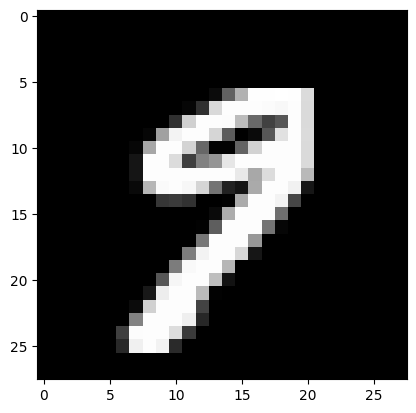

In [ ]:
val_index = 100
Z1val, A1val, Z2val, A2val = forward_propogation(W1, B1, W2, B2, x_val[:, val_index, None])
print("Predicted label: ", get_predictions(A2val))
print("Actual label: ", y_val[val_index])

image_array = x_val[:,val_index].reshape(28,28)
plt.imshow(image_array, cmap='gray')
plt.show()